# 🧱 Homework: Příprava dat pro regresní modely – Pevnost betonu
**Dataset:** *Concrete Compressive Strength* (I-Cheng Yeh, 1998)  
**Cíl:** Příprava datové sady pro regresní modely odhadující pevnost betonu v tlaku ($csMPa$).

### Popis domény & proměnných
Beton je heterogenní kompozitní materiál vznikající smícháním cementu, kameniva, vody a dalších přísad. V průběhu zrání dochází k hydrataci cementu a vytvrzování, čímž roste jeho pevnost v tlaku měřená v megapascalech (MPa).

| Proměnná | Fyzikální význam | Jednotka | Role |
| :--- | :--- | :--- | :--- |
| **`cement`** | Obsah cementu v záměsi | $	ext{kg/m}^3$ | Nezávislá (vstup) |
| **`slag`** | Vysokopecní struska (latentně hydraulická příměs) | $	ext{kg/m}^3$ | Nezávislá (vstup) |
| **`flyash`** | Popílek (pucolánová příměs) | $	ext{kg/m}^3$ | Nezávislá (vstup) |
| **`water`** | Záměsová voda | $	ext{kg/m}^3$ | Nezávislá (vstup) |
| **`superplasticizer`** | Superplastifikátor (snižuje potřebu vody při zachování tekutosti) | $	ext{kg/m}^3$ | Nezávislá (vstup) |
| **`coarseaggregate`** | Hrubé kamenivo (štěrk) | $	ext{kg/m}^3$ | Nezávislá (vstup) |
| **`fineaggregate`** | Jemné kamenivo (písek) | $	ext{kg/m}^3$ | Nezávislá (vstup) |
| **`age`** | Doba zrání betonu před testováním | dny ($1 - 365$) | Nezávislá (vstup) |
| **`csMPa`** | Pevnost v tlaku (Compressive Strength) | $	ext{MPa}$ | **Cílová (Target)** |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Konfigurace zobrazení
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## 1. Načtení datového souboru a přejmenování sloupců
Načteme soubor `data/concrete_data.csv`, ošetříme kódování a přiřadíme anglické názvy proměnných specifikované v zadání.


In [2]:
# Definice názvů sloupců dle zadání
col_names = [
    'cement', 'slag', 'flyash', 'water', 'superplasticizer',
    'coarseaggregate', 'fineaggregate', 'age', 'csMPa'
]

# Načtení dat
try:
    df = pd.read_csv('data/concrete_data.csv', encoding='latin1')
except Exception:
    df = pd.read_csv('data/concrete_data.csv', encoding='utf-8')

# Přejmenování sloupců
df.columns = col_names

print(f"Rozměry načteného datasetu: {df.shape[0]} řádků, {df.shape[1]} sloupců")
display(df.head(10))


Rozměry načteného datasetu: 1030 řádků, 9 sloupců


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.000,0.000,0.000,162.000,2.500,1040.000,676.000,28,79.986
1,540.000,0.000,0.000,162.000,2.500,1055.000,676.000,28,61.887
2,332.500,142.500,0.000,228.000,0.000,932.000,594.000,270,40.270
3,332.500,142.500,0.000,228.000,0.000,932.000,594.000,365,41.053
4,198.600,132.400,0.000,192.000,0.000,978.400,825.500,360,44.296
5,266.000,114.000,0.000,228.000,0.000,932.000,670.000,90,47.030
6,380.000,95.000,0.000,228.000,0.000,932.000,594.000,365,43.698
7,380.000,95.000,0.000,228.000,0.000,932.000,594.000,28,36.448
8,266.000,114.000,0.000,228.000,0.000,932.000,670.000,28,45.854
9,475.000,0.000,0.000,228.000,0.000,932.000,594.000,28,39.290


## 2. Kontrola prázdných hodnot a datových typů
Ověříme přítomnost chybějících hodnot (`NaN` / `null`) a zkontrolujeme, zda jsou všechny proměnné numerického typu.


In [3]:
# Informace o datových typech a paměťové náročnosti
print("=== INFO O STRUKTUŘE DAT ===")
df.info()

print("\n=== POČET CHYBĚJÍCÍCH HODNOT (ISNA) ===")
missing_series = df.isna().sum()
display(missing_series.to_frame(name='Počet NaN'))


=== INFO O STRUKTUŘE DAT ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cement            1030 non-null   float64
 1   slag              1030 non-null   float64
 2   flyash            1030 non-null   float64
 3   water             1030 non-null   float64
 4   superplasticizer  1030 non-null   float64
 5   coarseaggregate   1030 non-null   float64
 6   fineaggregate     1030 non-null   float64
 7   age               1030 non-null   int64  
 8   csMPa             1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB

=== POČET CHYBĚJÍCÍCH HODNOT (ISNA) ===


,Počet NaN
cement,0
slag,0
flyash,0
water,0
superplasticizer,0
coarseaggregate,0
fineaggregate,0
age,0
csMPa,0


## 3. Detekce a odstranění duplicitních záznamů
V laboratorních měřeních betonu mohou vznikat duplicitní záznamy. Prověříme jejich výskyt a duplicity odstraníme.


In [4]:
# Kontrola duplicit
num_duplicates = df.duplicated().sum()
print(f"Počet nalezených duplicitních řádků: {num_duplicates}")

if num_duplicates > 0:
    print("\nUkázka duplicitních vzorků (seřazeno pro porovnání):")
    display(df[df.duplicated(keep=False)].sort_values(by=col_names).head(6))
    
    # Odstranění duplicit
    df_clean = df.drop_duplicates().copy().reset_index(drop=True)
    print(f"\nPůvodní počet řádků: {len(df)}")
    print(f"Počet řádků po odstranění duplicit: {len(df_clean)}")
else:
    df_clean = df.copy()


Počet nalezených duplicitních řádků: 25

Ukázka duplicitních vzorků (seřazeno pro porovnání):


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
801,252.000,0.000,0.000,185.000,0.000,1111.000,784.000,28,19.691
809,252.000,0.000,0.000,185.000,0.000,1111.000,784.000,28,19.691
83,362.600,189.000,0.000,164.900,11.600,944.700,755.800,3,35.301
86,362.600,189.000,0.000,164.900,11.600,944.700,755.800,3,35.301
88,362.600,189.000,0.000,164.900,11.600,944.700,755.800,3,35.301
91,362.600,189.000,0.000,164.900,11.600,944.700,755.800,3,35.301



Původní počet řádků: 1030
Počet řádků po odstranění duplicit: 1005


## 4. Popisná statistika a rozdělení proměnných
Vypočteme základní statistiky: průměr, směrodatnou odchylku, kvartily, šikmost (*skewness*) a podíl nulových hodnot (mnoho směsí neobsahuje strusku, popílek nebo plastifikátor).


In [5]:
desc_stats = df_clean.describe().T
desc_stats['skewness'] = df_clean.skew()
desc_stats['zeros_pct'] = (df_clean == 0).mean() * 100

display(desc_stats[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness', 'zeros_pct']])


,mean,std,min,25%,50%,75%,max,skewness,zeros_pct
cement,278.629,104.345,102.000,190.680,265.000,349.000,540.000,0.565,0.000
slag,72.043,86.171,0.000,0.000,20.000,142.500,359.400,0.855,46.269
flyash,55.535,64.207,0.000,0.000,0.000,118.270,200.100,0.497,53.831
water,182.074,21.341,121.750,166.610,185.700,192.940,247.000,0.034,0.000
superplasticizer,6.032,5.920,0.000,0.000,6.100,10.000,32.200,0.982,37.612
coarseaggregate,974.376,77.580,801.000,932.000,968.000,1031.000,1145.000,-0.065,0.000
fineaggregate,772.687,80.340,594.000,724.300,780.000,822.200,992.600,-0.252,0.000
age,45.857,63.735,1.000,7.000,28.000,56.000,365.000,3.254,0.000
csMPa,35.250,16.285,2.332,23.524,33.798,44.868,82.599,0.396,0.000


## 5. Vizualizace rozdělení (Histogramy)
Generujeme histogramy s odhadem hustoty pravděpodobnosti (KDE) pro všech 9 proměnných.


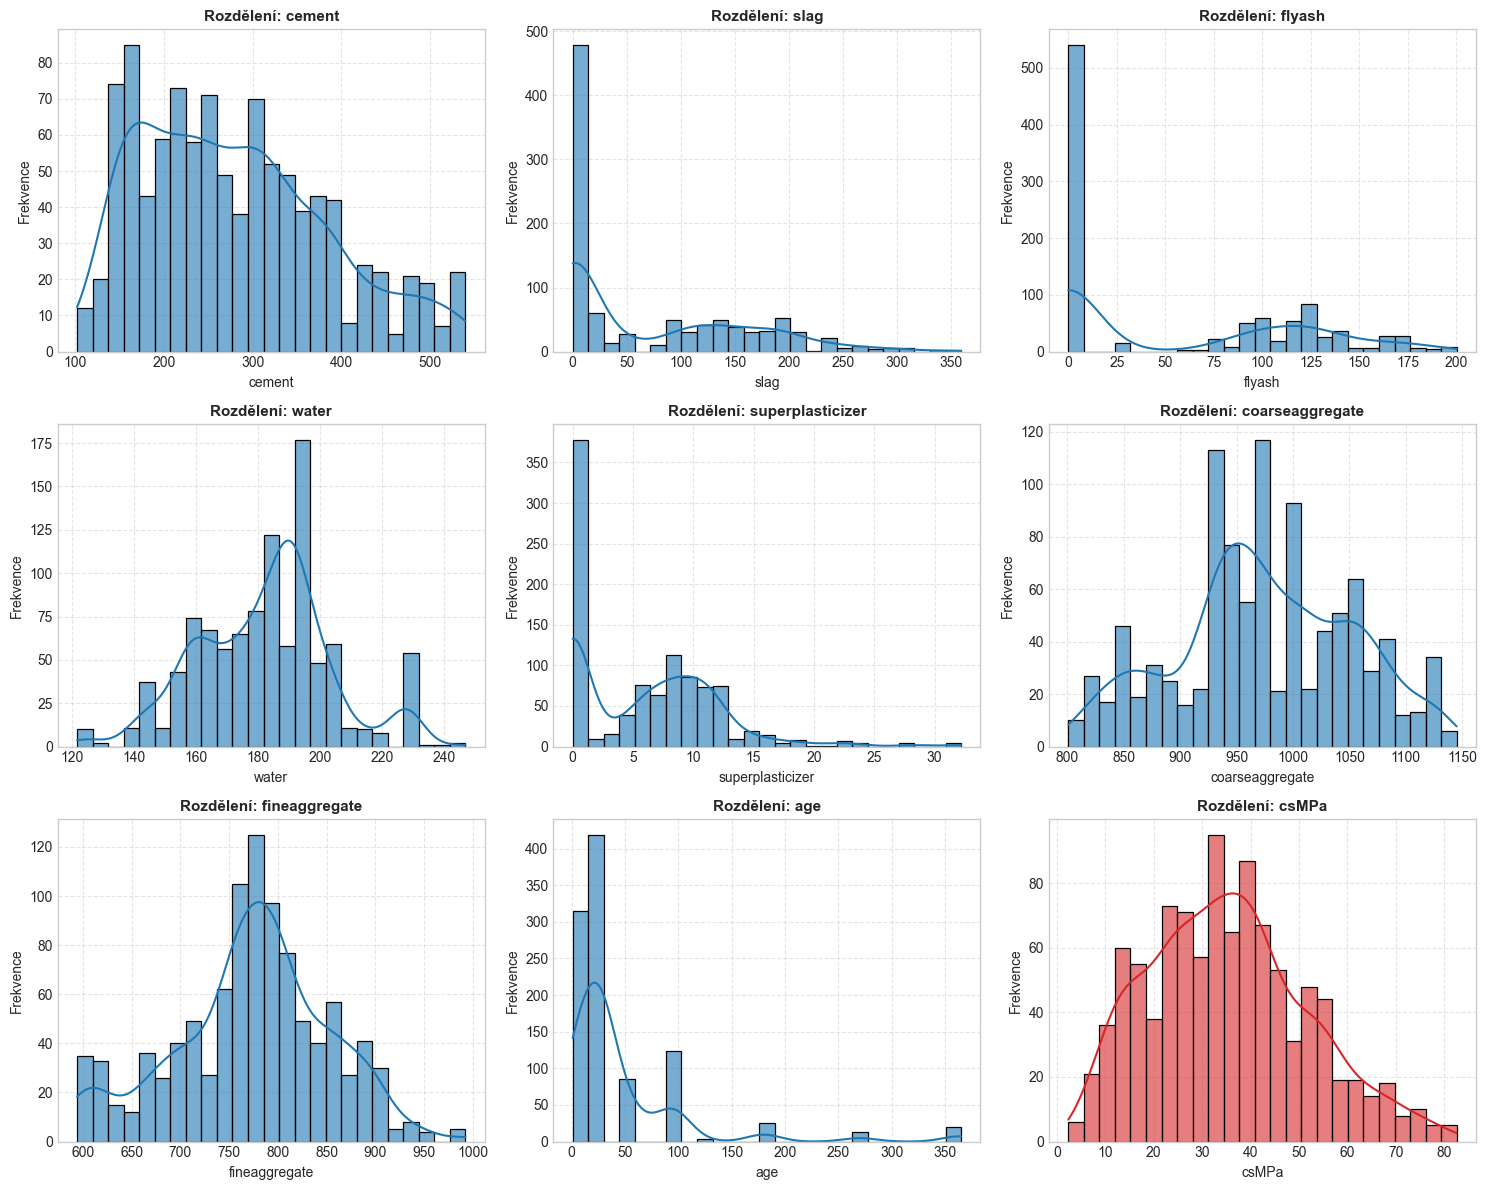

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(col_names):
    ax = axes[idx]
    color = '#1f77b4' if col != 'csMPa' else '#d62728'
    sns.histplot(df_clean[col], kde=True, ax=ax, color=color, bins=25, edgecolor='black', alpha=0.6)
    ax.set_title(f"Rozdělení: {col}", fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel("Frekvence")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 6. Závislost nezávislých proměnných na pevnosti betonu (Scatter plots)
Sledujeme závislosti jednotlivých složek směsi na výsledné pevnosti v tlaku `csMPa`.


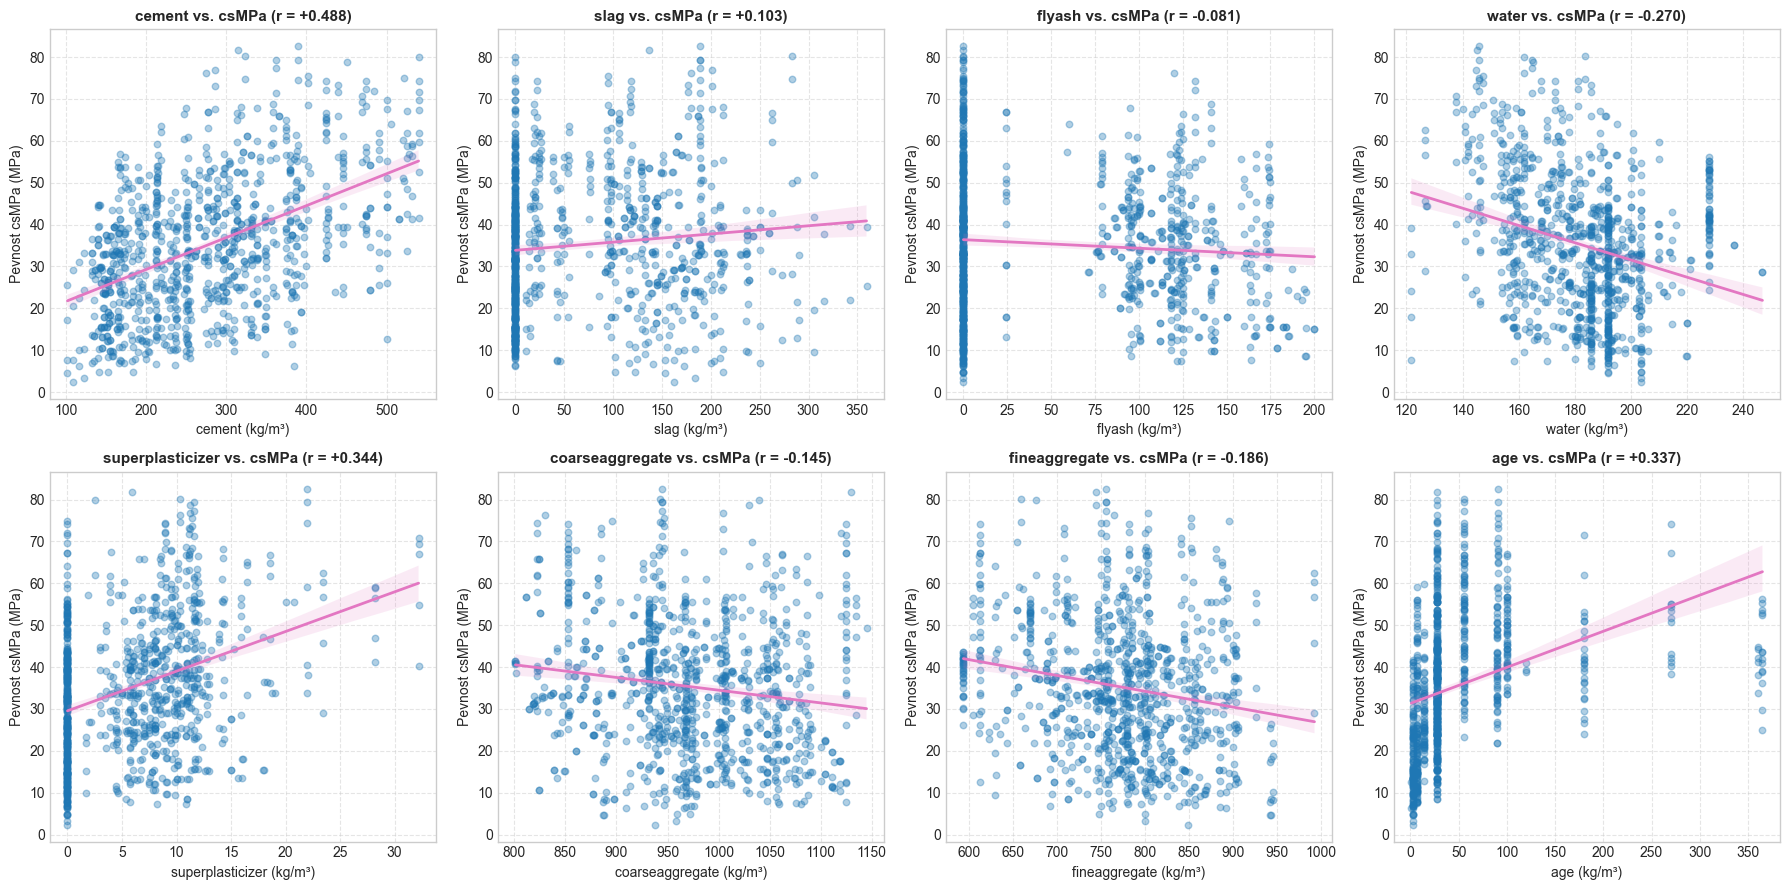

In [7]:
feature_cols = col_names[:-1]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    ax = axes[idx]
    r_val = df_clean[col].corr(df_clean['csMPa'])
    sns.regplot(
        data=df_clean, x=col, y='csMPa', ax=ax,
        scatter_kws={'alpha': 0.35, 'color': '#1f77b4', 's': 22},
        line_kws={'color': '#e377c2', 'linewidth': 2}
    )
    ax.set_title(f"{col} vs. csMPa (r = {r_val:+.3f})", fontsize=11, fontweight='bold')
    ax.set_xlabel(f"{col} (kg/m³)")
    ax.set_ylabel("Pevnost csMPa (MPa)")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 7. Korelační analýza (Pearsonova matice)
Analyzujeme lineární vztahy mezi složkami směsi a vzájemnou multikolinearitu (např. kompenzaci vody superplastifikátorem).


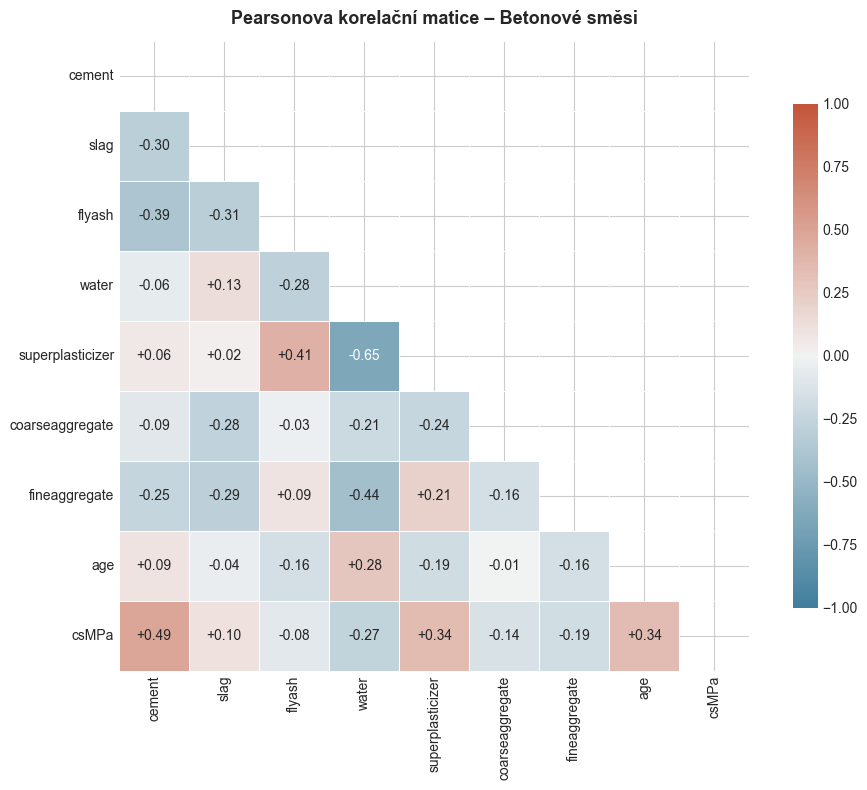


=== POŘADÍ KORELACÍ S Pevností csMPa ===


,Korelace r
csMPa,1.000
cement,0.488
superplasticizer,0.344
age,0.337
slag,0.103
flyash,-0.081
coarseaggregate,-0.145
fineaggregate,-0.186
water,-0.270


In [8]:
plt.figure(figsize=(10, 8))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr, mask=mask, annot=True, fmt="+.2f",
    cmap=cmap, vmax=1.0, vmin=-1.0, center=0,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}
)
plt.title("Pearsonova korelační matice – Betonové směsi", fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print("\n=== POŘADÍ KORELACÍ S Pevností csMPa ===")
display(corr['csMPa'].sort_values(ascending=False).to_frame(name='Korelace r'))


## 8. Škálování proměnných (StandardScaler vs. MinMaxScaler)
Pro lineární regresi s regularizací (Lasso, Ridge) a neuronové sítě je zásadní provést škálování prediktorů.

- **StandardScaler:** Transformuje příznaky na $z$-skóre ($\mu = 0, \sigma = 1$). Zachovává odlehlé hodnoty a je ideální pro penalizované regrese.
- **MinMaxScaler:** Transformuje hodnoty do pevného intervalu $[0, 1]$.


In [9]:
X = df_clean[feature_cols]
y = df_clean['csMPa']

# 1. Standardizace pomocí StandardScaler
std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(X)
df_std = pd.DataFrame(X_std, columns=feature_cols)
df_std['csMPa'] = y.round(2)

# 2. MinMax normalizace pro porovnání
minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)
df_minmax = pd.DataFrame(X_minmax, columns=feature_cols)
df_minmax['csMPa'] = y.round(2)

print("Statistika standardizovaných příznaků (StandardScaler):")
display(df_std[feature_cols].describe().round(3).T[['mean', 'std', 'min', 'max']])


Statistika standardizovaných příznaků (StandardScaler):


,mean,std,min,max
cement,-0.000,1.000,-1.694,2.506
slag,-0.000,1.000,-0.836,3.336
flyash,-0.000,1.000,-0.865,2.253
water,-0.000,1.000,-2.828,3.044
superplasticizer,0.000,1.000,-1.019,4.423
coarseaggregate,-0.000,1.000,-2.236,2.200
fineaggregate,-0.000,1.000,-2.225,2.739
age,-0.000,1.000,-0.704,5.010


### Vizuální porovnání distribucí před a po škálování

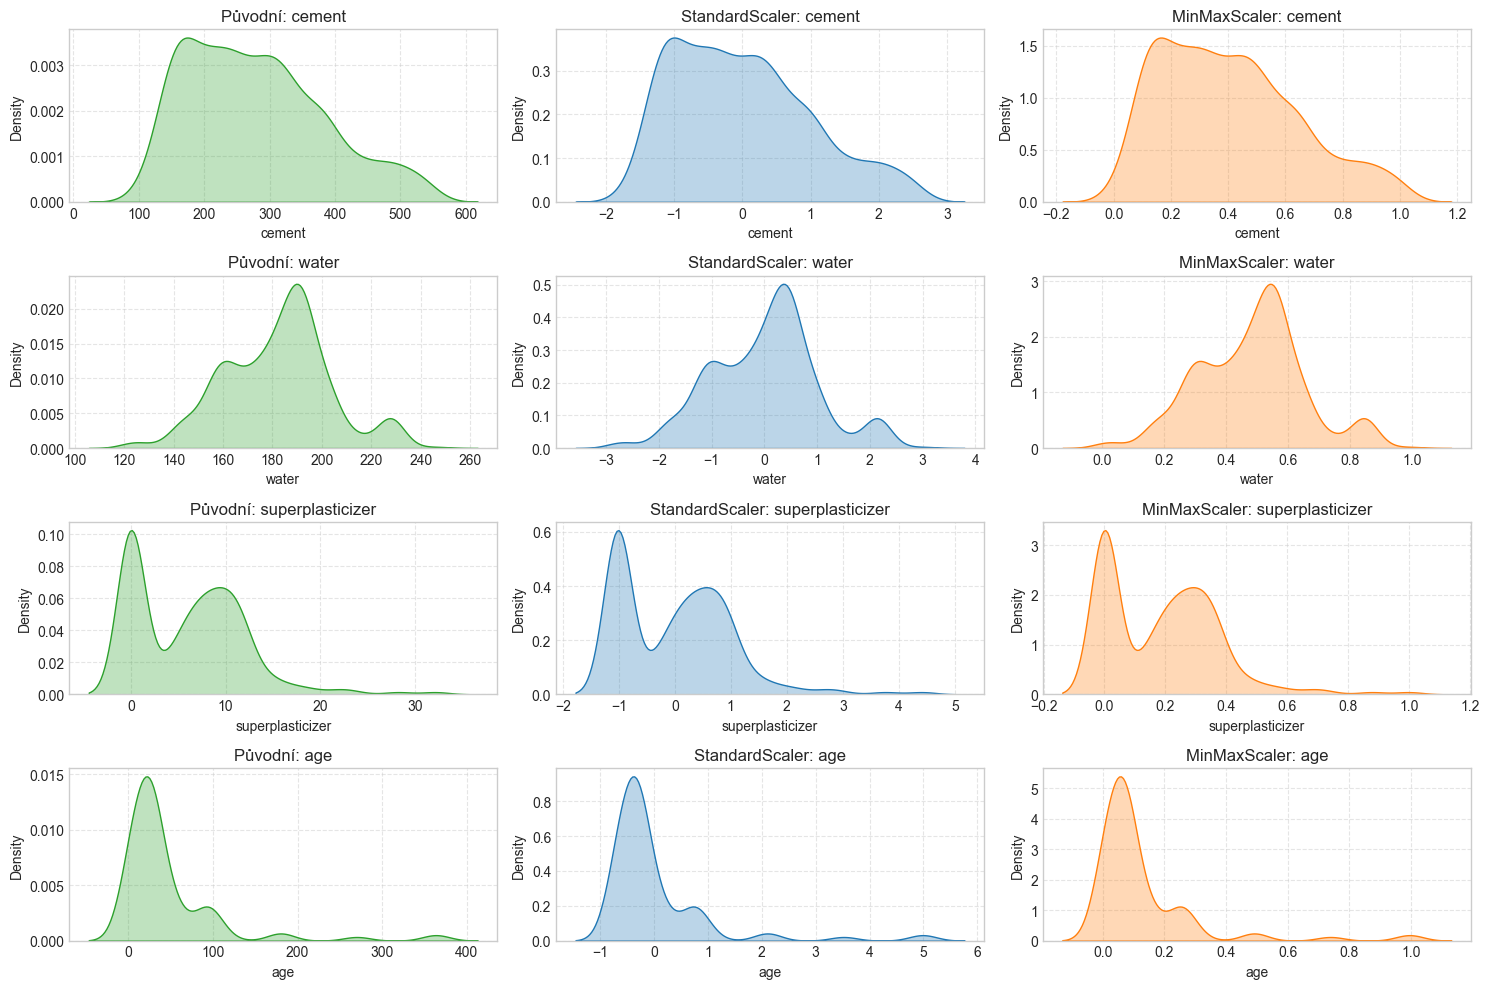

In [10]:
sample_cols = ['cement', 'water', 'superplasticizer', 'age']
fig, axes = plt.subplots(len(sample_cols), 3, figsize=(15, 10))

for i, col in enumerate(sample_cols):
    # Původní
    sns.kdeplot(df_clean[col], ax=axes[i, 0], color='#2ca02c', fill=True, alpha=0.3)
    axes[i, 0].set_title(f"Původní: {col}")
    axes[i, 0].grid(True, linestyle='--', alpha=0.5)
    
    # StandardScaler
    sns.kdeplot(df_std[col], ax=axes[i, 1], color='#1f77b4', fill=True, alpha=0.3)
    axes[i, 1].set_title(f"StandardScaler: {col}")
    axes[i, 1].grid(True, linestyle='--', alpha=0.5)
    
    # MinMaxScaler
    sns.kdeplot(df_minmax[col], ax=axes[i, 2], color='#ff7f0e', fill=True, alpha=0.3)
    axes[i, 2].set_title(f"MinMaxScaler: {col}")
    axes[i, 2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 9. Uložení předzpracovaného datasetu
Výsledný standardizovaný dataset ukládáme jako `data/concrete_data_preprocessed.csv`.
Tento dataset bude sloužit jako vstup pro navazující úlohy stavby regresních modelů.


In [11]:
output_path = 'data/concrete_data_preprocessed.csv'
df_std.to_csv(output_path, index=False)
print(f"Úspěšně uložen soubor: {output_path}")
print(f"Výsledné rozměry: {df_std.shape[0]} řádků, {df_std.shape[1]} sloupců")
display(df_std.head(10))


Úspěšně uložen soubor: data/concrete_data_preprocessed.csv
Výsledné rozměry: 1005 řádků, 9 sloupců


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,2.506,-0.836,-0.865,-0.941,-0.597,0.846,-1.204,-0.280,79.990
1,2.506,-0.836,-0.865,-0.941,-0.597,1.040,-1.204,-0.280,61.890
2,0.517,0.818,-0.865,2.153,-1.019,-0.547,-2.225,3.519,40.270
3,0.517,0.818,-0.865,2.153,-1.019,-0.547,-2.225,5.010,41.050
4,-0.767,0.701,-0.865,0.465,-1.019,0.052,0.658,4.931,44.300
5,-0.121,0.487,-0.865,2.153,-1.019,-0.547,-1.279,0.693,47.030
6,0.972,0.267,-0.865,2.153,-1.019,-0.547,-2.225,5.010,43.700
7,0.972,0.267,-0.865,2.153,-1.019,-0.547,-2.225,-0.280,36.450
8,-0.121,0.487,-0.865,2.153,-1.019,-0.547,-1.279,-0.280,45.850
9,1.883,-0.836,-0.865,2.153,-1.019,-0.547,-2.225,-0.280,39.290


## 10. Shrnutí a interpretace pro regresní modelování
1. **Kvalita dat:** Dataset neobsahuje žádné chybějící hodnoty (`0 NaN`). Bylo identifikováno a odstraněno **25 duplicitních záznamů**, čímž byl dataset očištěn na **1005 unikátních vzorků**.
2. **Klíčové faktory pevnosti:**
   - **`cement` ($r = +0.488$):** Nejsilnější pozitivní prediktor pevnosti betonu.
   - **`superplasticizer` ($r = +0.344$):** Zvyšuje pevnost nepřímo, protože umožňuje výrazně snížit obsah vody při zachování zpracovatelnosti směsi.
   - **`age` ($r = +0.337$):** Pevnost roste s časem logaritmicky (rychlý nárůst během prvních 28 dní, poté postupná saturace).
   - **`water` ($r = -0.270$):** Negativní vliv na pevnost (klasické pravidlo vodního součinitele $w/c$).
3. **Výběr metody škálování:** Byl zvolen **`StandardScaler`**, protože zachovává nulový průměr ($\mu=0$) a jednotkový rozptyl ($\sigma=1$), což zabraňuje nežádoucí deformaci vah v regularizovaných modelech (Ridge/Lasso) a optimalizaci gradientním sestupem.
